# Tail Risk Backtesting: When the Test Improves and the Model Does Not

A walkthrough of the tail-risk backtest and the null-sensitivity experiment.

**Article:** https://kwantil.com/papers/did-the-model-get-better/
**Scoreboard and methodology:** https://kwantil.com/var-backtest/

---

### What this notebook does

It reproduces the central result of the article from scratch: that an
expected-shortfall diagnostic improved because the *reference distribution*
moved, not because the model did.

The statistics are computed inline rather than called from a script. The point
of the finding is that a threshold estimated from data is a modelling decision,
and you cannot see that if the threshold arrives from inside a function you did
not open.

The library is used for two things only: fetching prices, and walking the
backtest forward. Both are slow and neither is where the argument lives.

Everything after that — the statistic, the reference distributions, the
thresholds, the factorial — is computed in the cells below and cross-checked,
bit for bit, against the library function and against the shipped result files.
Every headline number in the article is re-derived here and **asserted**, so
running this notebook tells you whether the paper still stands.

**A note on names.** Acerbi and Székely (2014) call the conditional statistic,
the one averaged over exceedance days, $Z_1$, and the unconditional one $Z_2$.
Version 1.0 of the article and of this code had the two names swapped. They are
now named as in the paper; no number changed.

### The arc

| Section | What happens |
|---|---|
| 1 | Set up, and get a backtest to work with |
| 2 | Build the conditional Z1 statistic by hand, so it is not a black box |
| 3 | Ask the question the test cannot answer on its own: what is *too* negative? |
| 4 | Build a null distribution and watch a threshold appear |
| 5 | Change only the null. Nothing else. Six times |
| 6 | Separate the model change from the test change with a factorial |
| 7 | Find the limit: what can this test detect at all? |
| 8 | Re-run with the unconditional Z2, and score 2 models known to be broken |
| 9 | What none of this supports |

### How to run this

**Install.** Python 3.11, from the analysis root
(`analyses/var-backtest-tail-risk`):

```bash
pip install -e .          # numpy, scipy, pandas, pyarrow, yfinance, arch, pydantic
pip install matplotlib    # notebook only; not a package dependency
```

The notebook works from `notebooks/` or from the analysis root; the setup cell
works out which.

**Data.** No prices ship with this repository — Yahoo Finance terms do not
permit redistributing them — so two files have to be built, once:

| File | Built by | Cost |
|---|---|---|
| `experiments/factorial/t/details.csv` | `python scripts/run_backtest.py --copula t --no-dashboard --output-dir experiments/factorial/t` | ~6 min |
| `experiments/factorial/gaussian/details.csv` | `python scripts/run_backtest.py --copula gaussian --no-dashboard --output-dir experiments/factorial/gaussian` | ~6 min |

The first of those also downloads and caches SPY, TLT and GLD closes. No account
and no API key. `experiments/factorial/*/as_null_sensitivity.csv` **is**
committed, so the cross-checks against the shipped pipeline in section 4 need no
rebuild. Full detail in `DATA.md`.

Every cell that opens a file goes through `need()`, so a missing input stops with
its own name and the command that builds it, not a traceback.

**How long.** A cold run is **about 13 minutes**, 12 of them the two backtest
arms. With both `details.csv` files already present it is **about 30 seconds**,
almost all of that the 50-null sweep in section 4. Every cell costing more than
a few seconds is flagged in the markdown directly above it.

**Skipping the expensive steps.** Set `AUTO_BUILD = False` in the setup cell and
the two backtest cells stop with the command to run instead of silently starting
a six-minute subprocess.

| Section | Needs |
|---|---|
| 1 | nothing beyond the imports |
| 2–5, 7, 8 | the **t** arm only (one 6-minute build) |
| 6 | both arms (the second 6-minute build) |
| 9 | prose; no computation |

Sections 2 and 7 each contain one cell that imports `var_backtest_uq` to check
the hand-written statistic against the library's. Without `pip install -e .`
those two cells fail and everything else still runs — the environment cell
below says whether it is installed.

**What a successful run looks like.** Every headline number in the article is
re-derived here and `assert`ed at the point it is produced. The notebook running
to the end *is* the check; there is nothing to eyeball.

## 1. Setup

No data ships with this repository. Prices come from Yahoo Finance on first run
and are cached locally. See `DATA.md`.

In [1]:
from __future__ import annotations

from importlib.metadata import PackageNotFoundError, version as package_version
from pathlib import Path
from typing import Callable
import platform
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Run from notebooks/ or from the analysis root; both work.
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

# The two backtest arms cost about 6 minutes each. With AUTO_BUILD = True a
# missing arm is built on the spot; with False the cell stops and prints the
# command instead, so nothing long starts without you asking for it. Either way
# an arm that already exists is reused and costs nothing.
AUTO_BUILD = True

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)

# Plain plots. The article figures are styled; these are for reading numbers.
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "font.size": 10,
})

INK, CLAY, MADDER, GOLD, SLATE = "#1a1815", "#8a4b23", "#8f2620", "#937212", "#2f4d78"


def need(rel: str, how: str) -> Path:
    """Fail with instructions rather than a bare traceback.

    Every cell that opens a file goes through this, so a missing input names
    itself and the command that builds it instead of surfacing as a
    FileNotFoundError forty lines into a stack trace.
    """
    p = ROOT / rel
    if not p.exists():
        raise SystemExit(
            f"Missing {rel}\n"
            f"  Build it with, from {ROOT}:\n"
            f"    {how}\n"
            f"  Full guide: DATA.md, or the 'How to run this' cell at the top."
        )
    return p


print("analysis root:", ROOT.name)
print("AUTO_BUILD   :", AUTO_BUILD)

analysis root: var-backtest-tail-risk
AUTO_BUILD   : True


### The environment this ran in

A seeded result is only reproducible against a fixed stack. A different numpy or
scipy can move a seeded draw in the last few digits; a different `yfinance` can
return a differently-adjusted price series, which moves everything downstream of
it. Neither is hypothetical and neither announces itself.

So the versions actually loaded are printed here, next to the versions the
published numbers were produced with. **If a number below disagrees with the
article, this table is the first place to look.** A mismatch is not an error and
nothing here fails on one.

In [2]:
# Versions this notebook was last run against end to end, with every assertion
# passing. Not a pin — `pyproject.toml` holds the real floors — just a record
# of a stack known to produce the published numbers.
VERIFIED_PYTHON = "3.11.9"
VERIFIED_WITH = {
    "numpy": "2.2.6",
    "pandas": "2.2.3",
    "scipy": "1.17.1",
    "matplotlib": "3.10.1",       # notebook only; not a package dependency
    "arch": "7.2.0",              # rebuild only: the GARCH fits inside run_backtest.py
    "yfinance": "1.2.0",          # rebuild only: the price pull
    "pyarrow": "19.0.1",          # rebuild only: the price cache
    "var-backtest-uq": "0.1.0",   # this analysis, from `pip install -e .`
}


def installed(dist: str) -> str:
    """Version of an installed distribution, or a marker. Imports nothing."""
    try:
        return package_version(dist)
    except PackageNotFoundError:
        return "not installed"


print(f"platform    {platform.platform()}")
print()
print(f"{'package':16s} {'in use':16s} {'verified with':16s}")
print("-" * 52)

table = [("python", platform.python_version(), VERIFIED_PYTHON)]
table += [(dist, installed(dist), want) for dist, want in VERIFIED_WITH.items()]

differing = []
for dist, have, want in table:
    flag = "" if have == want else "   <- differs"
    if flag:
        differing.append(dist)
    print(f"{dist:16s} {have:16s} {want:16s}{flag}")

print()
if differing:
    print("Differing from the verified stack: " + ", ".join(differing))
    print("That is normal on a fresh install and is not an error. It is the")
    print("first thing to check if a number here differs from the article.")
else:
    print("Exact match with the verified stack.")

if installed("var-backtest-uq") == "not installed":
    print()
    print("var-backtest-uq is NOT installed. The two cells that cross-check")
    print("against the library (sections 2 and 7) will fail on import; every")
    print("other cell still runs.  Fix:  pip install -e .   from", ROOT)

platform    Windows-10-10.0.19045-SP0

package          in use           verified with   
----------------------------------------------------
python           3.11.9           3.11.9          
numpy            2.2.6            2.2.6           
pandas           2.2.3            2.2.3           
scipy            1.17.1           1.17.1          
matplotlib       3.10.1           3.10.1          
arch             7.2.0            7.2.0           
yfinance         1.2.0            1.2.0           
pyarrow          19.0.1           19.0.1          
var-backtest-uq  0.1.0            0.1.0           

Exact match with the verified stack.


### The claims this notebook has to survive

Re-deriving a result proves nothing on its own: a notebook that quietly computes
different numbers than the article and prints them without comment is worse than
no notebook. So the published values are written down here, once, and asserted
at the point each one is produced. They come from
[`README.md`](../README.md) and the article.

| Claim | Value | Checked in |
|---|---|---|
| The model change (Gaussian → t copula) moves the statistic by | **+0.0096** | § 6 |
| The test change (Gaussian → Student-t reference) moves the threshold by | **−0.104** | § 6 |
| … so the test did this much of the work | **≈11×** | § 6 |
| Green cells under a Gaussian reference, out of 10 | **0** | § 4 |
| Green cells under a df-5 reference, out of 10 | **10** | § 4 |
| Green cells under the shipped moment-matched reference, out of 10 | **6** | § 4 |
| `parametric` breaches at twice its rate and is *still* not rejected under the empirical null | **not rejected** | § 7 |
| Green cells for $Z_2$ under each of the 5 parametric references, out of 10 | **6** | § 8 |
| VaR × 0.8 model: $Z_2$ red under all 5 parametric references, $Z_1$ green under the shipped one | **yes** | § 8 |
| Gaussian-tail model: $Z_2$ green under all 6 references | **yes** | § 8 |

**The tolerances, and why they are what they are.** Two different kinds of
quantity are being checked and they deserve different slack.

*Observed statistics* — $Z_1$, $Z_2$, breach counts, the copula effect — contain **no
Monte Carlo inside this notebook**. They are arithmetic on `details.csv`. The
only wobble is upstream, in the seeded copula simulation that produced the VaR
and ES. `TOL_STAT = 5e-4` is roughly 5% of the +0.0096 copula effect: tight
enough that a real regression trips it, loose enough to survive a numpy or scipy
release that shifts a seeded draw.

*Thresholds* are the 5th percentile of a 2,000-draw bootstrap. Re-running the
sweep under five different seeds moved that percentile with a standard deviation
of about **0.0023**. The null effect is a difference of two such percentiles, so
its own sd is around 0.003. `TOL_THRESHOLD = 0.010` is about 3.3 of those —
wide enough that bootstrap noise never fails the notebook, narrow enough to be a
real check on a number published as −0.104.

The zone *counts* are integers and are asserted exactly. That is only safe
because no asserted cell sits near its boundary, and § 4 prints the margins so
you can see that rather than take it on trust.

In [3]:
# The published claims. Asserted at the point each is produced, not printed as
# decoration: if one fails, the notebook stops and names the article value.
PUBLISHED = {
    "copula_effect": +0.0096,   # model change: Gaussian copula -> t copula
    "null_effect": -0.104,      # test change: Gaussian ref -> Student-t ref
    "work_ratio": 11.0,         # |null_effect / copula_effect|
    "green_gaussian": 0,        # of 10 (method x alpha) cells
    "green_t_df5": 10,
    "green_shipped": 6,
    "z2_green_each_parametric": 6,  # section 8: same count under all 5 parametric nulls
    "n_days": 2172,
    "n_methods": 5,
}

# Derivations for both tolerances are in the markdown above.
TOL_STAT = 5e-4        # arithmetic on details.csv; no Monte Carlo in-notebook
TOL_THRESHOLD = 0.010  # ~3.3 sd of the 2,000-draw 5th-percentile bootstrap
TOL_RATIO = 1.0        # the 11x is quoted to the nearest integer

N_SIM = 2_000          # matches scripts/as_null_sensitivity.py exactly
SEED = 4242            # ditto, so thresholds here reproduce the shipped ones

print(f"{len(PUBLISHED)} published claims loaded")
print(f"tolerances: stat +/-{TOL_STAT}, threshold +/-{TOL_THRESHOLD}, ratio +/-{TOL_RATIO}")

9 published claims loaded
tolerances: stat +/-0.0005, threshold +/-0.01, ratio +/-1.0


### Get a backtest to work with

Five forecasters, two confidence levels, 2,172 graded trading days, walk-forward.
The models are fitted on a rolling window and every forecast is made before the
day it is scored against, so nothing sees its own exam.

> **Slow cell below — about 6 minutes, once.** It shells out to
> `scripts/run_backtest.py` only when `experiments/factorial/t/details.csv` is
> missing, and is **skipped entirely once that file exists**. The first build
> also downloads and caches SPY/TLT/GLD closes from Yahoo Finance, which needs a
> network connection but no key. With `AUTO_BUILD = False` the cell stops and
> prints the command instead of starting the subprocess.

This arm is what sections 2 through 5 and section 7 read. Only section 6 needs
the second arm.

In [4]:
DETAILS_REL = "experiments/factorial/t/details.csv"
BUILD_T = ("python scripts/run_backtest.py --copula t --no-dashboard "
           "--output-dir experiments/factorial/t")

if not (ROOT / DETAILS_REL).exists() and AUTO_BUILD:
    (ROOT / DETAILS_REL).parent.mkdir(parents=True, exist_ok=True)
    print("running the backtest, about 6 minutes...")
    subprocess.run(
        [sys.executable, "scripts/run_backtest.py", "--copula", "t",
         "--no-dashboard", "--output-dir", "experiments/factorial/t"],
        cwd=ROOT, check=True,
    )

# Guards both the AUTO_BUILD = False path and a build that ran but wrote nothing.
DETAILS = need(DETAILS_REL, BUILD_T)

d = pd.read_csv(DETAILS, parse_dates=["date"])
per_cell = d.groupby(["method", "alpha"]).size().unique()
print(f"{len(d):,} rows | {d.method.nunique()} methods | "
      f"alphas {[float(a) for a in sorted(d.alpha.unique())]}")
print(f"graded days per (method, alpha): {[int(x) for x in per_cell]}")
print(f"columns: {list(d.columns)}")

assert len(per_cell) == 1 and int(per_cell[0]) == PUBLISHED["n_days"], (
    f"article says {PUBLISHED['n_days']:,} graded trading days per cell; got {per_cell}"
)
assert d.method.nunique() == PUBLISHED["n_methods"], (
    f"article says {PUBLISHED['n_methods']} forecasters; got {d.method.nunique()}"
)
d.head(3)

21,720 rows | 5 methods | alphas [0.01, 0.025]
graded days per (method, alpha): [2172]
columns: ['date', 'method', 'alpha', 'var', 'es', 'breached', 'realized_pnl', 'pnl_mu', 'pnl_sigma', 'pnl_kurt_excess']


,date,method,alpha,var,es,breached,realized_pnl,pnl_mu,pnl_sigma,pnl_kurt_excess
0,2018-01-02,parametric,0.025,-0.006305,-0.007520,False,0.002778,0.000000,0.003217,0.000000
1,2018-01-02,parametric,0.010,-0.007483,-0.008573,False,0.002778,0.000000,0.003217,0.000000
2,2018-01-02,historical,0.025,-0.005985,-0.006867,False,0.002778,0.000513,0.003436,0.115392


Each row is one model's forecast for one day at one confidence level:

- `var` — the loss level the model said would be exceeded with probability
  $\alpha$
- `es` — the average loss the model expected *given* an exceedance
- `realized_pnl` — what actually happened
- `pnl_mu`, `pnl_sigma`, `pnl_kurt_excess` — the moments of the distribution the
  model predicted that morning. These matter later: the reference distribution
  is built from them.

Sign convention throughout: **losses are negative**, so `var` and `es` are
negative and `es < var`.

## 2. The statistic, built by hand

An exceedance is a day the loss went past the quoted VaR:

$$b_t = \mathbb{1}[X_t < \mathrm{VaR}_t]$$

Counting those tests the VaR promise directly. **Expected shortfall is a
different claim**: not how often you breach, but how bad it is when you do. The
conditional Acerbi–Székely statistic, $Z_1$, compares realised losses on
exceedance days against the ES the model predicted:

$$Z_1 = \frac{1}{N_{br}}\sum_{t\,:\,b_t=1} \frac{X_t}{|\mathrm{ES}_t|} + 1$$

If the model's ES is right, each ratio averages $-1$ and $Z_1$ averages $0$.
Negative $Z_1$ means realised losses ran deeper than promised.

Because it divides by the number of exceedances that happened, $Z_1$ cannot see
whether there were too many of them. Acerbi and Székely pair it with an
exceedance-count test for that reason. Their unconditional $Z_2$ divides by the
number the model expected, $T\alpha$, instead; section 8 uses it.

In [5]:
def z1_statistic(realized: np.ndarray, var: np.ndarray, es: np.ndarray) -> float:
    """Acerbi-Szekely Z1. Averages the shortfall ratio over exceedance days.

    Written out here instead of imported because the argument of this notebook
    is that you cannot audit a threshold you never watched being built. The
    library's version is asserted equal to this one two cells down.
    """
    breach = realized < var
    if breach.sum() == 0:
        return np.nan
    return float(np.mean(realized[breach] / np.abs(es[breach])) + 1.0)


def slice_arrays(
    frame: pd.DataFrame, method: str, alpha: float
) -> tuple[np.ndarray, ...]:
    """One (method, alpha) cell as date-sorted arrays.

    The sort is load-bearing: the empirical null in section 7 rebuilds
    standardised residuals from this ordering, so a differently-ordered frame
    would silently change the resampling pool.
    """
    g = frame[(frame.method == method) & (frame.alpha == alpha)].sort_values("date")
    return (g.realized_pnl.to_numpy(), g["var"].to_numpy(), g.es.to_numpy(),
            g.pnl_mu.to_numpy(), g.pnl_sigma.to_numpy(), g.pnl_kurt_excess.to_numpy())


ALPHA = 0.01
rows = []
for m in sorted(d.method.unique()):
    r, v, e, *_ = slice_arrays(d, m, ALPHA)
    br = r < v
    rows.append({"method": m, "n_days": len(r), "exceedances": int(br.sum()),
                 "rate": br.mean(), "target": ALPHA, "Z1": z1_statistic(r, v, e)})

by_hand = pd.DataFrame(rows).sort_values("Z1")
by_hand

,method,n_days,exceedances,rate,target,Z1
4,parametric,2172,45,0.020718,0.01,-0.167155
3,historical,2172,38,0.017495,0.01,-0.155891
1,conformal_pid_es,2172,24,0.011050,0.01,-0.134701
2,distributional,2172,17,0.007827,0.01,-0.016690
0,conformal_pid,2172,24,0.011050,0.01,0.009216


Two things worth pausing on.

**`parametric` breaches at about twice its stated rate.** That is a model failing
in the most basic way a risk model can. Remember it: any test worth running
should also reject it.

**Cross-check against the library**, so the hand computation is not quietly
wrong.

In [6]:
from var_backtest_uq.backtest.acerbi_szekely import acerbi_szekely_test_1

r, v, e, *_ = slice_arrays(d, "conformal_pid", ALPHA)
lib = acerbi_szekely_test_1(r, v, e, sample_under_h0=None)

print(f"by hand : {z1_statistic(r, v, e):+.10f}")
print(f"library : {lib['statistic']:+.10f}")
assert abs(z1_statistic(r, v, e) - lib["statistic"]) < 1e-12
print("\nidentical. the hand version is the real statistic.")

# The two numbers section 3 opens with, checked rather than merely asserted in prose.
z1_by_method = by_hand.set_index("method").Z1
rate_by_method = by_hand.set_index("method").rate

print(f"\nconformal_pid  Z1 = {z1_by_method['conformal_pid']:+.4f}   (article: +0.009)")
print(f"parametric     Z1 = {z1_by_method['parametric']:+.4f}   (article: -0.167)")
print(f"parametric breach rate = {rate_by_method['parametric']:.4f} "
      f"= {rate_by_method['parametric'] / ALPHA:.2f}x its stated {ALPHA}")

assert abs(z1_by_method["conformal_pid"] - 0.009) < 1e-3, (
    f"article quotes conformal_pid Z1 = +0.009; got {z1_by_method['conformal_pid']:+.4f}"
)
assert abs(z1_by_method["parametric"] - (-0.167)) < 1e-3, (
    f"article quotes parametric Z1 = -0.167; got {z1_by_method['parametric']:+.4f}"
)
assert rate_by_method["parametric"] > 1.8 * ALPHA, (
    "article calls parametric a model breaching at about twice its stated rate; got "
    f"{rate_by_method['parametric'] / ALPHA:.2f}x"
)

by hand : +0.0092158107
library : +0.0092158107

identical. the hand version is the real statistic.

conformal_pid  Z1 = +0.0092   (article: +0.009)
parametric     Z1 = -0.1672   (article: -0.167)
parametric breach rate = 0.0207 = 2.07x its stated 0.01


## 3. The question the statistic cannot answer

Conformal-PID scores $Z_1 = +0.009$. Parametric scores $-0.167$.

Is $-0.167$ **bad**? There is no table to look it up in. A $t$-statistic has a
$t$ distribution; $Z_1$ has no closed-form null, because its distribution depends
on the model's own predicted distribution and on how many exceedances happened.

So the threshold has to be **simulated**. That is standard, and it is correct for
a specification test: the hypothesis is *the distribution this model claimed is
the right one*, so the null has to encode the model's claim.

The procedure:

1. Take the distribution the model predicted for each day.
2. Draw a whole alternative history of P&L from it.
3. Score $Z_1$ on that fake history, using the model's real VaR and ES.
4. Repeat. The 5th percentile of the resulting spread is the green threshold.

**Step 1 is where the modelling decision hides**, and it is the subject of this
notebook.

### Building a null, one draw at a time

`pnl_mu` and `pnl_sigma` are the model's predicted mean and standard deviation
for each day. The simplest null draws Gaussian from them.

In [7]:
def draw_null_z1(
    sampler: Callable[[np.random.Generator, int], np.ndarray],
    var: np.ndarray,
    es: np.ndarray,
    n_sim: int = N_SIM,
    seed: int = SEED,
) -> np.ndarray:
    """Simulate the null distribution of Z1 under a given P&L sampler.

    One draw at a time, in a visible loop, because the loop is where the
    modelling decision lives: `sampler` is the only thing that changes anywhere
    below, and everything downstream of it is fixed arithmetic.

    The defaults match `scripts/as_null_sensitivity.py` (2,000 draws, seed
    4242), so the thresholds computed here are directly comparable with the
    shipped result files rather than merely close to them.
    """
    rng = np.random.default_rng(seed)
    out = []
    for _ in range(n_sim):
        x_sim = sampler(rng, len(var))
        z = z1_statistic(x_sim, var, es)
        if not np.isnan(z):
            out.append(z)
    return np.array(out)


r, v, e, mu, sigma, kurt = slice_arrays(d, "conformal_pid", ALPHA)


def make_gaussian_sampler(
    mu: np.ndarray, sigma: np.ndarray
) -> Callable[[np.random.Generator, int], np.ndarray]:
    """The thin reference: N(mu_t, sigma_t) from the model's own first two moments.

    A factory rather than a bare function so every reference below is built the
    same way, closing over the arrays it was handed. `make_t_sampler` in
    section 4 has the same shape, which is what makes the sweep a clean
    one-variable swap.
    """

    def sampler(rng: np.random.Generator, n: int) -> np.ndarray:
        return mu + sigma * rng.standard_normal(n)

    return sampler


gaussian = make_gaussian_sampler(mu, sigma)

null_gauss = draw_null_z1(gaussian, v, e)
obs = z1_statistic(r, v, e)
thr_gauss = np.percentile(null_gauss, 5)

print(f"null draws kept    {null_gauss.size:,} of {N_SIM:,}  (a draw with no exceedance is dropped)")
print(f"observed Z1        {obs:+.4f}")
print(f"null mean          {null_gauss.mean():+.4f}")
print(f"null 5th pct       {thr_gauss:+.4f}   <- the green threshold")
print(f"verdict            {'PASS' if obs >= thr_gauss else 'FAIL'}")
print()
print("Note the null mean. A reference consistent with the model's own ES would")
print("centre near 0. It does not, because the VaR and ES came from a t-copula")
print("Monte Carlo while this reference is Gaussian. The reference and the model")
print("already disagree before any data is scored, and that offset is pure")
print("assumption. Keep an eye on it as the reference changes below.")

null draws kept    2,000 of 2,000  (a draw with no exceedance is dropped)
observed Z1        +0.0092
null mean          +0.0680
null 5th pct       +0.0192   <- the green threshold
verdict            FAIL

Note the null mean. A reference consistent with the model's own ES would
centre near 0. It does not, because the VaR and ES came from a t-copula
Monte Carlo while this reference is Gaussian. The reference and the model
already disagree before any data is scored, and that offset is pure
assumption. Keep an eye on it as the reference changes below.


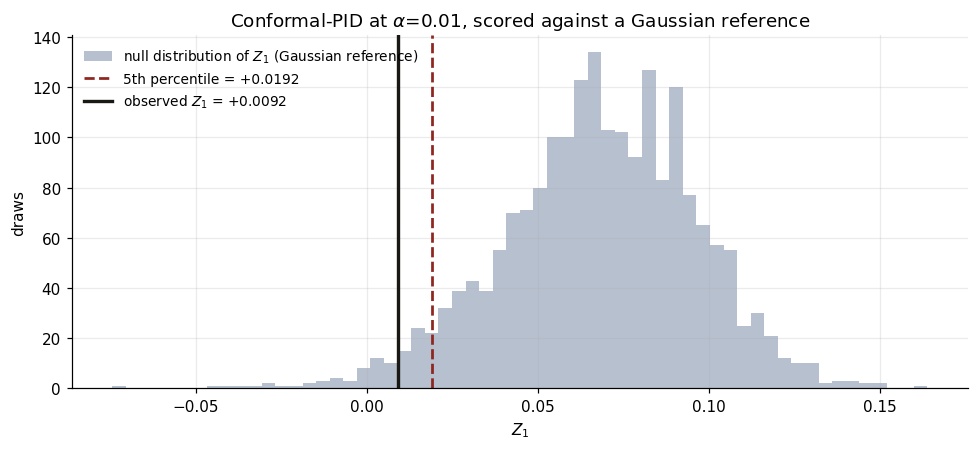

The observed statistic sits BELOW the threshold. Under this reference,
this model does not pass.


In [8]:
fig, ax = plt.subplots()
ax.hist(null_gauss, bins=60, color=SLATE, alpha=0.35, edgecolor="none",
        label="null distribution of $Z_1$ (Gaussian reference)")
ax.axvline(thr_gauss, color=MADDER, lw=1.8, ls="--",
           label=f"5th percentile = {thr_gauss:+.4f}")
ax.axvline(obs, color=INK, lw=2.2, label=f"observed $Z_1$ = {obs:+.4f}")
ax.set_xlabel("$Z_1$"); ax.set_ylabel("draws")
ax.set_title("Conformal-PID at $\\alpha$=0.01, scored against a Gaussian reference")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

print("The observed statistic sits BELOW the threshold. Under this reference,")
print("this model does not pass.")

## 4. Change only the reference

Nothing about the model, the data, the VaR or the ES changes from here. The
observed statistic is **fixed**. Only the reference distribution moves, and with
it the threshold.

The shipped implementation does not use a Gaussian. It uses a Student-$t$
moment-matched to the model's own predicted kurtosis:

$$\nu = 4 + \frac{6}{\kappa}, \qquad \kappa = \operatorname{median}_t\,\kappa_t$$

which inverts the Student-$t$ excess-kurtosis identity $\kappa = 6/(\nu-4)$.

In [9]:
from scipy.stats import t as student_t


def make_t_sampler(
    mu: np.ndarray, sigma: np.ndarray, df: float
) -> Callable[[np.random.Generator, int], np.ndarray]:
    """Student-t with the given df, rescaled to preserve sigma.

    The rescale is what makes the sweep below an experiment rather than a mess:
    without it, changing df would move the *variance* of the reference as well
    as its shape, and the threshold shift could no longer be attributed to the
    tail assumption alone. The 4.5 floor keeps the kurtosis identity 6/(df-4)
    and the variance rescale finite, matching the library's
    `student_t_h0_sampler`.
    """
    df = max(float(df), 4.5)
    scale = sigma * np.sqrt((df - 2.0) / df)

    def sampler(rng: np.random.Generator, n: int) -> np.ndarray:
        return mu + scale * student_t.rvs(df=df, size=n, random_state=rng)

    return sampler


kappa = float(np.median(kurt))
df_shipped = 4.0 + 6.0 / kappa
print(f"model's median predicted excess kurtosis  kappa = {kappa:.3f}")
print(f"implied degrees of freedom                df    = {df_shipped:.3f}")

model's median predicted excess kurtosis  kappa = 1.470
implied degrees of freedom                df    = 8.083


In [10]:
NULLS = {
    "Gaussian":                 gaussian,
    "Student-t, df 15":         make_t_sampler(mu, sigma, 15),
    f"moment-matched t (df {df_shipped:.1f}, SHIPPED)": make_t_sampler(mu, sigma, df_shipped),
    "Student-t, df 8":          make_t_sampler(mu, sigma, 8),
    "Student-t, df 5":          make_t_sampler(mu, sigma, 5),
}

sweep = []
dists = {}
for name, sampler in NULLS.items():
    null = draw_null_z1(sampler, v, e)
    dists[name] = null
    thr = np.percentile(null, 5)
    sweep.append({"reference": name, "Z1 (fixed)": obs,
                  "green threshold": thr, "p-value": float((null <= obs).mean()),
                  "verdict": "pass" if obs >= thr else "fail"})

sweep_df = pd.DataFrame(sweep)
assert sweep_df["Z1 (fixed)"].nunique() == 1, "the observed statistic must not move"
sweep_df

,reference,Z1 (fixed),green threshold,p-value,verdict
0,Gaussian,0.009216,0.019190,0.0255,fail
1,"Student-t, df 15",0.009216,-0.030312,0.2545,pass
2,"moment-matched t (df 8.1, SHIPPED)",0.009216,-0.084734,0.6565,pass
3,"Student-t, df 8",0.009216,-0.089524,0.6695,pass
4,"Student-t, df 5",0.009216,-0.190164,0.9415,pass


#### Is this the shipped null, or only something that resembles it?

Worth settling before the sweep is used to argue anything. The five samplers
above were written from the formula, not imported; if they differ from the ones
the pipeline actually uses, this notebook is a nice illustration of a different
experiment.

`experiments/factorial/t/as_null_sensitivity.csv` is the shipped output of
`scripts/as_null_sensitivity.py`. It carries the green threshold for every
(method, alpha, null). The samplers here use the same draw count and the same
seed, so agreement should be exact — not "within tolerance", *exact*. Anything
looser would mean the two constructions differ somewhere and the difference is
merely small.

In [11]:
SHIPPED_T = need(
    "experiments/factorial/t/as_null_sensitivity.csv",
    "python scripts/as_null_sensitivity.py --details experiments/factorial/t/details.csv",
)
shipped = pd.read_csv(SHIPPED_T)
print(f"{len(shipped)} shipped rows | nulls: {sorted(shipped.null.unique())}")
print(shipped.head(3).to_string(index=False))

# Names differ between the notebook (readable) and the script (filesystem-safe).
NULL_NAME_MAP = {
    "Gaussian": "gaussian",
    "Student-t, df 15": "t_df15",
    f"moment-matched t (df {df_shipped:.1f}, SHIPPED)": "t_moment",
    "Student-t, df 8": "t_df8",
    "Student-t, df 5": "t_df5",
}

pid = shipped[(shipped.method == "conformal_pid") & (shipped.alpha == ALPHA)]
pid = pid.set_index("null")

print("\n                                        notebook      shipped        diff")
for name, row in zip(sweep_df.reference, sweep_df["green threshold"]):
    ref = float(pid.loc[NULL_NAME_MAP[name], "z1_green_threshold"])
    print(f"{name:38s} {row:+.8f}  {ref:+.8f}  {row - ref:+.1e}")
    assert abs(row - ref) < 1e-12, (
        f"{name}: notebook threshold {row:+.8f} != shipped {ref:+.8f}. "
        "Same seed and draw count, so this is a construction difference, not noise."
    )

obs_shipped = float(pid.z1.iloc[0])
assert abs(obs - obs_shipped) < 1e-12, (
    f"observed Z1 {obs:+.8f} != shipped {obs_shipped:+.8f}"
)
print("\nEvery threshold agrees to machine precision. These are the shipped nulls.")

84 shipped rows | nulls: ['empirical', 'gaussian', 't_df15', 't_df5', 't_df8', 't_moment']
     arm               method  alpha     null  df_used  kurt_median  n_breaches  kupiec_pvalue        z1 z1_zone  z1_p_value  z1_green_threshold  z1_yellow_threshold        z2 z2_zone  z2_p_value  z2_green_threshold  z2_yellow_threshold
t_copula broken_gauss_matched   0.01 gaussian      NaN          0.0          24         0.6726 -0.074754  yellow       0.008           -0.044754            -0.091003 -0.187573   green       0.182           -0.384522            -0.777803
t_copula broken_gauss_matched   0.01 t_moment      NaN          0.0          24         0.6726 -0.074754  yellow       0.008           -0.044754            -0.091003 -0.187573   green       0.182           -0.384522            -0.777803
t_copula broken_gauss_matched   0.01    t_df5      5.0          0.0          24         0.6726 -0.074754   green       0.955           -0.281285            -0.443713 -0.187573   green       0.969   

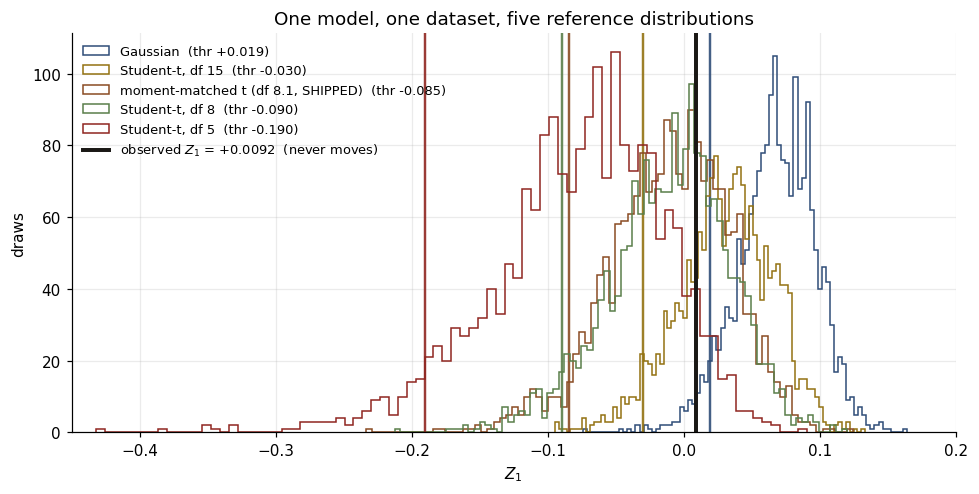

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.6))
colors = [SLATE, GOLD, CLAY, "#5a7f4a", MADDER]

for (name, null), c in zip(dists.items(), colors):
    thr = np.percentile(null, 5)
    ax.axvline(thr, color=c, lw=1.6, alpha=0.9)
    ax.hist(null, bins=80, histtype="step", lw=1.3, color=c, label=f"{name}  (thr {thr:+.3f})")

ax.axvline(obs, color=INK, lw=2.6, label=f"observed $Z_1$ = {obs:+.4f}  (never moves)")
ax.set_xlim(-0.45, 0.2)
ax.set_xlabel("$Z_1$"); ax.set_ylabel("draws")
ax.set_title("One model, one dataset, five reference distributions")
ax.legend(frameon=False, fontsize=8.5, loc="upper left")
plt.tight_layout(); plt.show()

**The black line is the model. Everything else is an assumption.**

The observed statistic is identical in every row. The verdict changes because the
threshold slides from `+0.019` under a Gaussian reference to roughly `-0.19`
under a df-5 one. Same number, opposite conclusions.

### Does this hold across all five models?

One model could be a coincidence. Run the sweep over every model and both
confidence levels: 10 cells.

> **Slow cell below — 15 to 30 seconds, every time.** 50 null distributions
> (5 methods x 2 alphas x 5 references) at 2,000 draws each. Nothing is cached,
> so re-running the cell pays the cost again. It reads no new data; it is pure
> Monte Carlo on the arm already loaded.

In [13]:
def zone_for(obs_z1: float, null: np.ndarray) -> str:
    """Green above the 5th percentile, red below the 0.1th, yellow between.

    The two percentiles are the whole verdict. Both are properties of `null`
    and neither touches the model, which is the point being made.
    """
    if obs_z1 >= np.percentile(null, 5.0):
        return "green"
    return "yellow" if obs_z1 >= np.percentile(null, 0.1) else "red"


records = []
for method in sorted(d.method.unique()):
    for alpha in sorted(d.alpha.unique()):
        r_, v_, e_, mu_, sg_, ku_ = slice_arrays(d, method, alpha)
        o = z1_statistic(r_, v_, e_)
        k = float(np.median(ku_))
        # Matches the shipped guard: negligible kurtosis falls back to Gaussian.
        df_ = 4.0 + 6.0 / k if k > 0.1 else None
        refs = {
            "Gaussian": make_gaussian_sampler(mu_, sg_),
            "t df15": make_t_sampler(mu_, sg_, 15),
            "shipped": (make_t_sampler(mu_, sg_, df_) if df_
                        else make_gaussian_sampler(mu_, sg_)),
            "t df8": make_t_sampler(mu_, sg_, 8),
            "t df5": make_t_sampler(mu_, sg_, 5),
        }
        for name, samp in refs.items():
            null = draw_null_z1(samp, v_, e_)
            thr = float(np.percentile(null, 5.0))
            records.append({"method": method, "alpha": alpha, "reference": name,
                            "kappa": k, "Z1": o, "threshold": thr,
                            # How far the cell is from flipping colour.
                            "margin": o - thr,
                            "zone": zone_for(o, null)})

grid = pd.DataFrame(records)
counts = (grid.groupby("reference").zone.value_counts().unstack(fill_value=0)
              .reindex(columns=["green", "yellow", "red"], fill_value=0)
              .reindex(["Gaussian", "t df15", "shipped", "t df8", "t df5"]))
print(f"{len(grid)} cells = {d.method.nunique()} methods x {d.alpha.nunique()} alphas x 5 references")
counts

50 cells = 5 methods x 2 alphas x 5 references


zone,green,yellow,red
reference,,,
Gaussian,0,3,7
t df15,5,2,3
shipped,6,1,3
t df8,7,3,0
t df5,10,0,0


The counts are integers, and a count is a fragile thing to assert: one cell
sitting a hair from its threshold could flip on a different seed and change the
headline. So before asserting them, look at how much room each cell has.

The same cross-check as before, now over all 50 cells rather than five.

In [14]:
merged = (grid.assign(null=grid.reference.map({
              "Gaussian": "gaussian", "t df15": "t_df15", "shipped": "t_moment",
              "t df8": "t_df8", "t df5": "t_df5"}))
              .merge(shipped, on=["method", "alpha", "null"]))

print(f"{len(merged)} of {len(grid)} cells matched against the shipped file")
print(f"zone disagreements      : {(merged.zone != merged.z1_zone).sum()}")
print(f"max |threshold diff|    : {(merged.threshold - merged.z1_green_threshold).abs().max():.2e}")
print(f"max |Z1 diff|           : {(merged.Z1 - merged.z1).abs().max():.2e}")
assert len(merged) == len(grid)
assert (merged.zone == merged.z1_zone).all(), "zone disagreement with the shipped file"
assert (merged.threshold - merged.z1_green_threshold).abs().max() < 1e-12

# Closest call under each reference: how far the observed Z1 sits from the
# threshold, in units of the ~0.0023 bootstrap sd of that threshold.
print("\nclosest cell to its green threshold, per reference:")
for ref, g in grid.groupby("reference"):
    tight = g.loc[g.margin.abs().idxmin()]
    print(f"  {ref:9s} {tight.method:16s} a={tight.alpha:<6} "
          f"margin {tight.margin:+.4f}  ({abs(tight.margin) / 0.0023:.1f} sd)")

green = counts["green"]
for key, ref, article in (("green_gaussian", "Gaussian", "0 green under a Gaussian null"),
                          ("green_t_df5", "t df5", "10 green under a df-5 null"),
                          ("green_shipped", "shipped", "6 green under the shipped null")):
    assert int(green[ref]) == PUBLISHED[key], (
        f"README says {article}; got {int(green[ref])} of {len(grid) // 5}"
    )
print(f"\nzone counts hold: Gaussian {green['Gaussian']}, "
      f"shipped {green['shipped']}, df-5 {green['t df5']} green out of {len(grid) // 5}.")
print("t df8 is deliberately not asserted: its 7th green cell sits inside a")
print("standard deviation of the boundary and does flip under other seeds.")

50 of 50 cells matched against the shipped file
zone disagreements      : 0
max |threshold diff|    : 9.71e-17
max |Z1 diff|           : 9.54e-17

closest cell to its green threshold, per reference:
  Gaussian  conformal_pid    a=0.01   margin -0.0100  (4.3 sd)
  shipped   historical       a=0.01   margin -0.0324  (14.1 sd)
  t df15    distributional   a=0.025  margin -0.0046  (2.0 sd)
  t df5     historical       a=0.025  margin +0.0370  (16.1 sd)
  t df8     parametric       a=0.01   margin +0.0035  (1.5 sd)

zone counts hold: Gaussian 0, shipped 6, df-5 10 green out of 10.
t df8 is deliberately not asserted: its 7th green cell sits inside a
standard deviation of the boundary and does flip under other seeds.


**Zero passes under a Gaussian reference. Everything passes under a df-5 one.**
The verdict published on a scoreboard is, to a first approximation, a statement
about the assumption behind the threshold.

## 5. The reference is built from the model's own claim

Here is the part that turns an inconvenience into a bias.

The degrees of freedom come from the model's *own predicted* kurtosis. A model
claiming fat tails gets a fat reference, a wide null, and a threshold far below
zero. A model claiming Gaussian tails gets a tight null and a threshold near
zero.

The parametric baseline predicts a Gaussian distribution, so its predicted excess
kurtosis is exactly 0 and it is scored against a Gaussian reference.

In [15]:
claim = (grid[(grid.reference == "shipped") & (grid.alpha == ALPHA)]
         [["method", "kappa", "Z1", "zone"]]
         .assign(implied_df=lambda t: np.where(t.kappa > 0.1, 4 + 6 / t.kappa, np.nan))
         .sort_values("kappa", ascending=False))
claim

,method,kappa,Z1,zone,implied_df
2,conformal_pid,1.469669,0.009216,green,8.082551
12,conformal_pid_es,1.469669,-0.134701,green,8.082551
22,distributional,1.412081,-0.016690,green,8.249048
32,historical,1.119072,-0.155891,yellow,9.361586
42,parametric,0.000000,-0.167155,red,NaN


The model claiming the fattest tails is judged against the most permissive
threshold. **Claiming fat tails buys a more lenient exam.**

An earlier revision of the methodology said the opposite, on the argument that a
thin claimed tail tightens the threshold and so makes the test *harder*. That
identifies a real channel and weighs it wrongly: there is a second channel
through the `|ES|` denominator, and the threshold channel dominates. The
measurement settled it. That reversal is recorded in the article rather than
quietly fixed.

## 6. Separating the model change from the test change

The article's origin: three things changed at once in a development revision —
a t-copula base, a Student-t reference, and a new method — and the changelog
credited the copula.

Two of those push the verdict the same way, for different reasons. A t-copula
widens the modelled tail, improving the *statistic*. A Student-t reference widens
the null, lowering the *bar*.

The factorial: both copulas crossed with both references. The copula needs a
rerun; the reference is applied after the fact and costs nothing.

> **Slow cell below — about 6 minutes, once.** The Gaussian-copula arm is a
> second full backtest, and this is the only section that needs it. Skipped once
> `experiments/factorial/gaussian/details.csv` exists; with `AUTO_BUILD = False`
> the cell stops and prints the command instead. The four null simulations after
> the load take about a second.

In [16]:
GAUSS_REL = "experiments/factorial/gaussian/details.csv"
BUILD_GAUSS = ("python scripts/run_backtest.py --copula gaussian --no-dashboard "
               "--output-dir experiments/factorial/gaussian")

if not (ROOT / GAUSS_REL).exists() and AUTO_BUILD:
    (ROOT / GAUSS_REL).parent.mkdir(parents=True, exist_ok=True)
    print("running the Gaussian-copula arm, about 6 minutes...")
    subprocess.run(
        [sys.executable, "scripts/run_backtest.py", "--copula", "gaussian",
         "--no-dashboard", "--output-dir", "experiments/factorial/gaussian"],
        cwd=ROOT, check=True,
    )

GAUSS_ARM = need(GAUSS_REL, BUILD_GAUSS)

dg = pd.read_csv(GAUSS_ARM, parse_dates=["date"])
print(f"gaussian-copula arm: {len(dg):,} rows | "
      f"{dg.groupby(['method', 'alpha']).size().unique()} days per cell")
assert set(dg.method) == set(d.method) and set(dg.alpha) == set(d.alpha), (
    "the two factorial arms must cover the same cells or the contrast is not a contrast"
)


cells_out = []
for cop_name, frame in (("gaussian copula", dg), ("t-copula (shipped)", d)):
    r_, v_, e_, mu_, sg_, ku_ = slice_arrays(frame, "conformal_pid", ALPHA)
    o = z1_statistic(r_, v_, e_)
    k = float(np.median(ku_))
    for ref_name, samp in (
        ("Gaussian reference", make_gaussian_sampler(mu_, sg_)),
        ("Student-t reference", make_t_sampler(mu_, sg_, 4 + 6 / k)),
    ):
        thr = np.percentile(draw_null_z1(samp, v_, e_), 5)
        cells_out.append({"copula": cop_name, "reference": ref_name,
                          "Z1": o, "threshold": thr,
                          "verdict": "pass" if o >= thr else "fail"})

fac = pd.DataFrame(cells_out)
fac

gaussian-copula arm: 21,720 rows | [2172] days per cell


,copula,reference,Z1,threshold,verdict
0,gaussian copula,Gaussian reference,-0.000425,0.020286,fail
1,gaussian copula,Student-t reference,-0.000425,-0.059711,pass
2,t-copula (shipped),Gaussian reference,0.009216,0.019190,fail
3,t-copula (shipped),Student-t reference,0.009216,-0.084734,pass


In [17]:
pick = lambda cop, ref: fac[(fac.copula == cop) & (fac.reference == ref)].iloc[0]

copula_effect = (pick("t-copula (shipped)", "Student-t reference").Z1
                 - pick("gaussian copula", "Student-t reference").Z1)
null_effect = (pick("t-copula (shipped)", "Student-t reference").threshold
               - pick("t-copula (shipped)", "Gaussian reference").threshold)
work_ratio = abs(null_effect / copula_effect)

print(f"changing the MODEL (copula)      moves the statistic by  {copula_effect:+.4f}"
      f"   (article: {PUBLISHED['copula_effect']:+.4f})")
print(f"changing the TEST  (reference)   moves the threshold by  {null_effect:+.4f}"
      f"   (article: {PUBLISHED['null_effect']:+.4f})")
print(f"\nthe test change did {work_ratio:.1f}x the work of the model change"
      f"   (article: ~{PUBLISHED['work_ratio']:.0f}x)")

# The headline of the article, asserted. TOL_STAT is arithmetic-only slack;
# TOL_THRESHOLD carries the bootstrap noise of two 5th percentiles.
assert abs(copula_effect - PUBLISHED["copula_effect"]) < TOL_STAT, (
    f"article: model change = {PUBLISHED['copula_effect']:+.4f}; "
    f"got {copula_effect:+.6f} (tol {TOL_STAT})"
)
assert abs(null_effect - PUBLISHED["null_effect"]) < TOL_THRESHOLD, (
    f"article: test change = {PUBLISHED['null_effect']:+.4f}; "
    f"got {null_effect:+.6f} (tol {TOL_THRESHOLD})"
)
assert abs(work_ratio - PUBLISHED["work_ratio"]) < TOL_RATIO, (
    f"article: the test did ~{PUBLISHED['work_ratio']:.0f}x the work of the model; "
    f"got {work_ratio:.2f}x (tol {TOL_RATIO})"
)
assert null_effect < 0 < copula_effect, (
    "the two effects must push the verdict the same way by opposite mechanisms: "
    "the statistic up, the bar down"
)

# The sharper claim, which is about a verdict rather than a magnitude.
still_fails = pick("t-copula (shipped)", "Gaussian reference")
assert still_fails.verdict == "fail", (
    "README: 'Against the original null, the improved model still fails.' "
    f"This run says {still_fails.verdict}."
)
print()
print("And the sharper version, from the table above: with the t-copula scored")
print("against the ORIGINAL Gaussian reference, the verdict is still a fail.")
print("The model change on its own never reached a pass. That verdict is")
print("asserted above, so this paragraph cannot drift away from the table.")

changing the MODEL (copula)      moves the statistic by  +0.0096   (article: +0.0096)
changing the TEST  (reference)   moves the threshold by  -0.1039   (article: -0.1040)

the test change did 10.8x the work of the model change   (article: ~11x)

And the sharper version, from the table above: with the t-copula scored
against the ORIGINAL Gaussian reference, the verdict is still a fail.
The model change on its own never reached a pass. That verdict is
asserted above, so this paragraph cannot drift away from the table.


## 7. What can this test actually detect?

A reference that is distribution-free about *shape* can be built by bootstrapping
the realised standardised residuals and re-applying each day's predicted scale.
That keeps the volatility structure and stops assuming a parametric tail.

Then ask the question from section 2: **does it reject the model that breaches at
twice its stated rate?**

In [18]:
from var_backtest_uq.backtest.coverage_tests import kupiec_pof


def empirical_sampler(
    mu: np.ndarray, sigma: np.ndarray, realized: np.ndarray
) -> Callable[[np.random.Generator, int], np.ndarray]:
    """Bootstrap standardised residuals, re-apply the per-day scale.

    Resampling the raw P&L would destroy the volatility clustering the models
    are forecasting, and the null would then be rejecting the wrong thing.
    Dividing by sigma_t first and multiplying it back keeps the scale path and
    frees only the shape.
    """
    z = (realized - mu) / np.where(sigma > 0, sigma, np.nan)
    pool = z[np.isfinite(z)]

    def sampler(rng: np.random.Generator, n: int) -> np.ndarray:
        return mu + sigma * rng.choice(pool, size=n, replace=True)

    return sampler


out = []
for method in sorted(d.method.unique()):
    r_, v_, e_, mu_, sg_, _ = slice_arrays(d, method, ALPHA)
    o = z1_statistic(r_, v_, e_)
    null = draw_null_z1(empirical_sampler(mu_, sg_, r_), v_, e_)
    br = (r_ < v_)
    # The exceedance-count test, computed here rather than cited: it is the
    # thing the ES test is being measured against.
    kup = kupiec_pof(br.astype(int), ALPHA)
    out.append({"method": method, "breach rate": br.mean(), "exceedances": int(br.sum()),
                "Z1": o, "threshold": np.percentile(null, 5),
                "p-value": float((null <= o).mean()),
                "zone": zone_for(o, null),
                "kupiec p": kup["p_value"]})

power = pd.DataFrame(out).sort_values("Z1")
power

,method,breach rate,exceedances,Z1,threshold,p-value,zone,kupiec p
4,parametric,0.020718,45,-0.167155,-0.233133,0.4640,green,0.0000
3,historical,0.017495,38,-0.155891,-0.349050,0.6980,green,0.0015
1,conformal_pid_es,0.011050,24,-0.134701,-0.239210,0.4195,green,0.6701
2,distributional,0.007827,17,-0.016690,-0.133941,0.5900,green,0.3386
0,conformal_pid,0.011050,24,0.009216,-0.112021,0.6715,green,0.6701


In [19]:
parametric = power.set_index("method").loc["parametric"]

print(f"parametric breaches {parametric['exceedances']} times in {PUBLISHED['n_days']:,} days "
      f"= {parametric['breach rate'] / ALPHA:.2f}x its stated {ALPHA} rate")
print(f"  exceedance-count test (Kupiec POF)  p = {parametric['kupiec p']:.5f}  -> rejected")
print(f"  ES test against the empirical null  p = {parametric['p-value']:.4f}  -> "
      f"{parametric['zone']}, threshold {parametric['threshold']:+.4f}, "
      f"observed {parametric['Z1']:+.4f}")
print(f"  the observed Z1 clears the bar by {parametric['Z1'] - parametric['threshold']:+.4f}, "
      "nowhere near a boundary")

# README: "under a distribution-free null nothing is rejected at all, including a
# baseline that breaches at twice its stated rate".
assert parametric["kupiec p"] < 0.001, (
    "section 7 claims parametric fails the exceedance-count test at p < 0.001; "
    f"got p = {parametric['kupiec p']:.5f}"
)
assert parametric["zone"] == "green", (
    "README: nothing is rejected under the empirical null, including parametric. "
    f"This run puts parametric in the {parametric['zone']} zone."
)
assert parametric["p-value"] > 0.10, (
    "the point is that parametric is not close to rejection, not merely unrejected; "
    f"got p = {parametric['p-value']:.4f}"
)
assert (power.zone == "green").all(), (
    "README: nothing is rejected under the empirical null. Non-green: "
    f"{sorted(power.loc[power.zone != 'green', 'method'])}"
)

# The range section 7 reasons about, computed rather than quoted.
exc = d.assign(b=d.realized_pnl < d["var"]).groupby(["method", "alpha"]).b.sum()
print(f"\nexceedances across all {len(exc)} cells: {exc.min()} to {exc.max()} "
      f"(article quotes 24 to 79)")
low_method, low_alpha = exc.idxmin()
print(f"  the cell below 24 is {low_method} at alpha={float(low_alpha)}, which "
      f"under-breaches at {exc.min() / PUBLISHED['n_days']:.4f}")

parametric breaches 45 times in 2,172 days = 2.07x its stated 0.01 rate
  exceedance-count test (Kupiec POF)  p = 0.00000  -> rejected
  ES test against the empirical null  p = 0.4640  -> green, threshold -0.2331, observed -0.1672
  the observed Z1 clears the bar by +0.0660, nowhere near a boundary

exceedances across all 10 cells: 17 to 79 (article quotes 24 to 79)
  the cell below 24 is distributional at alpha=0.01, which under-breaches at 0.0078


**Nothing is rejected. Including `parametric`, which breaches at twice its stated
rate and fails the exceedance-count test at p < 0.001.** That Kupiec p-value is
the `kupiec p` column above, computed on the same breach series, not quoted from
elsewhere.

Version 1.0 of the article read this as a sample-size limit. It is not one.
$Z_1$ averages over the exceedance days, so it cannot detect an excess number of
them at any sample size; that is why Acerbi and Székely pair it with a count
test, and here the count test did its job. The failure to reject `parametric`
is the design working, not the test running out of data.

What is left for $Z_1$ is tail depth, and there the sample size does bind: with
17 to 79 exceedances across the ten cells, $Z_1$ is an average over a few dozen
numbers. (The article's *24 to 79* is the range once `distributional` is set
aside; it is the one method that under-breaches, at 17.) The red and yellow
zones on the scoreboard are produced mainly by the narrowness of the parametric
reference, not by detected misspecification. Section 8 tests both kinds of error
directly.

## 8. The unconditional statistic, and 2 models known to be broken

Everything so far is about $Z_1$. The obvious question is whether it is a
property of ES backtesting or of that statistic. Acerbi and Székely report that
the critical value of the unconditional

$$Z_2 = \frac{1}{T\alpha}\sum_{t\,:\,b_t=1} \frac{X_t}{|\mathrm{ES}_t|} + 1$$

stays roughly fixed across Student-$t$ tails, which would make it much less
exposed to the choice of reference.

2 checks follow. First, their stability result, reproduced with *exact* nulls
(the VaR and ES are the true ones for the sampling distribution). Then the
sweep above re-run with $Z_2$ on the same simulated paths, plus 2 models broken
on purpose, one per kind of error:

- **VaR × 0.8**: Conformal-PID with VaR, ES and predicted scale all shrunk by
  0.8. Too many breaches, same tail shape. A frequency error.
- **Gaussian tail**: a Gaussian with Conformal-PID's VaR, so the same breach
  days, and the thinner Gaussian ES. A depth error.

> **Slow cell below — about 20 seconds.** 12 exact nulls at 2,000 draws each.

In [20]:
def z2_statistic(realized: np.ndarray, var: np.ndarray, es: np.ndarray, alpha: float) -> float:
    """Acerbi-Szekely Z2 (unconditional): the Z1 sum divided by T*alpha, not N_breach."""
    breach = realized < var
    return float(np.sum(realized[breach] / np.abs(es[breach])) / (len(realized) * alpha) + 1.0)


# The exact identity between the two, checked on real data before relying on it.
r, v, e, *_ = slice_arrays(d, "conformal_pid", ALPHA)
k_ratio = (r < v).sum() / (len(r) * ALPHA)
assert abs(z2_statistic(r, v, e, ALPHA) - (1 + k_ratio * (z1_statistic(r, v, e) - 1))) < 1e-12

# Acerbi-Szekely stability, with exact nulls: VaR and ES are the true ones.
from scipy.stats import norm

rows = []
for a in (0.01, 0.025):
    for df in (3, 5, 8, 15, 100, None):
        rng = np.random.default_rng(7)
        if df is None:
            q = norm.ppf(a); es_true = -norm.pdf(q) / a
            draw = lambda: rng.standard_normal(PUBLISHED["n_days"])
        else:
            q = student_t.ppf(a, df)
            es_true = -(df + q * q) / (df - 1) * student_t.pdf(q, df) / a
            draw = lambda: student_t.rvs(df, size=PUBLISHED["n_days"], random_state=rng)
        vv = np.full(PUBLISHED["n_days"], q); ee = np.full(PUBLISHED["n_days"], es_true)
        z1s, z2s = [], []
        for _ in range(N_SIM):
            x = draw()
            z = z1_statistic(x, vv, ee)
            if not np.isnan(z):
                z1s.append(z)
            z2s.append(z2_statistic(x, vv, ee, a))
        rows.append({"alpha": a, "df": df or "Gaussian",
                     "Z1 5th pct": np.percentile(z1s, 5), "Z2 5th pct": np.percentile(z2s, 5)})

exact = pd.DataFrame(rows)
for a, g in exact.groupby("alpha"):
    r1 = g["Z1 5th pct"].max() - g["Z1 5th pct"].min()
    r2 = g["Z2 5th pct"].max() - g["Z2 5th pct"].min()
    print(f"alpha {a}: range of the 5th percentile across tails  Z1 {r1:.3f}   Z2 {r2:.3f}")
    assert r2 < 0.5 * r1, "Z2's exact-null threshold should be far more stable than Z1's"
exact

alpha 0.01: range of the 5th percentile across tails  Z1 0.190   Z2 0.080
alpha 0.025: range of the 5th percentile across tails  Z1 0.113   Z2 0.046


,alpha,df,Z1 5th pct,Z2 5th pct
0,0.010,3,-0.234020,-0.440994
1,0.010,5,-0.106244,-0.366095
2,0.010,8,-0.075912,-0.381563
3,0.010,15,-0.059552,-0.361261
4,0.010,100,-0.045347,-0.378281
5,0.010,Gaussian,-0.043592,-0.367606
6,0.025,3,-0.146950,-0.272300
7,0.025,5,-0.074350,-0.238617
8,0.025,8,-0.055569,-0.226717
9,0.025,15,-0.042490,-0.236559


With exact nulls, the $Z_2$ threshold barely moves across tail shapes while the
$Z_1$ threshold moves several-fold. That is the Acerbi–Székely result.

The sweep in section 4 does not use exact nulls. It uses moment-matched
approximations, and their breach rates do not match the model's own VaR. $Z_2$
responds to the number of breaches, so it should move with that mismatch. The
shipped sweep has both statistics and both broken models; read them.

In [21]:
REAL = sorted(d.method.unique())
PARAM = ["gaussian", "t_df15", "t_moment", "t_df8", "t_df5"]
BROKEN = ["broken_scaled_0.8", "broken_gauss_matched"]
assert set(BROKEN) <= set(shipped.method), (
    "shipped sweep predates the broken models; re-run scripts/as_null_sensitivity.py"
)

# 1. The Z1 cells in the shipped file are the ones section 4 rebuilt, so the Z2
#    columns beside them come from the same simulated paths.
real = shipped[shipped.method.isin(REAL)]
z2_counts = (real.groupby("null").z2_zone.value_counts().unstack(fill_value=0)
                 .reindex(columns=["green", "yellow", "red"], fill_value=0)
                 .reindex(PARAM + ["empirical"]))
print("Z2 zone counts over the 10 real cells:")
print(z2_counts.to_string())
for nl in PARAM:
    assert z2_counts.loc[nl, "green"] == PUBLISHED["z2_green_each_parametric"], nl

# 2. How far each threshold travels across the 5 parametric nulls.
pid = shipped[(shipped.method == "conformal_pid") & (shipped.alpha == ALPHA) & shipped.null.isin(PARAM)]
print(f"\nconformal_pid a={ALPHA}: Z1 threshold {pid.z1_green_threshold.max():+.3f} to "
      f"{pid.z1_green_threshold.min():+.3f}; Z2 threshold {pid.z2_green_threshold.max():+.3f} to "
      f"{pid.z2_green_threshold.min():+.3f}")

# 3. The 4 non-green Z2 cells are the models the count test rejects.
non_green = real[real.null.isin(PARAM) & (real.z2_zone != "green")]
print("\nmethods Z2 fails under some parametric null:", sorted(non_green.method.unique()))
assert (non_green.kupiec_pvalue < 0.05).all()

# 4. The broken models.
b = shipped[shipped.method.isin(BROKEN) & (shipped.alpha == ALPHA)].set_index(["method", "null"])
sc, gm = "broken_scaled_0.8", "broken_gauss_matched"
print(f"\nVaR x 0.8     breaches {int(b.loc[(sc, 'gaussian'), 'n_breaches'])}, "
      f"Kupiec p = {b.loc[(sc, 'gaussian'), 'kupiec_pvalue']:.4f}, "
      f"Z1 = {b.loc[(sc, 'gaussian'), 'z1']:+.4f}, Z2 = {b.loc[(sc, 'gaussian'), 'z2']:+.4f}")
print(b.loc[sc][["z1_zone", "z1_p_value", "z2_zone", "z2_p_value"]].to_string())
print(f"\nGaussian tail breaches {int(b.loc[(gm, 'gaussian'), 'n_breaches'])}, "
      f"Kupiec p = {b.loc[(gm, 'gaussian'), 'kupiec_pvalue']:.4f}")
print(b.loc[gm][["z1_zone", "z1_p_value", "z2_zone", "z2_p_value"]].to_string())

assert b.loc[(sc, "gaussian"), "kupiec_pvalue"] < 0.001
assert (b.loc[sc].loc[PARAM].z2_zone == "red").all(), "Z2 should reject the frequency error"
assert b.loc[(sc, "t_moment"), "z1_zone"] == "green", "Z1 cannot see the frequency error"
assert (b.loc[gm].z2_zone == "green").all(), "Z2 passes the depth error under every null"
assert (b.loc[sc].loc["empirical"].z1_zone == "green") and (b.loc[sc].loc["empirical"].z2_zone == "green")

Z2 zone counts over the 10 real cells:
z2_zone    green  yellow  red
null                         
gaussian       6       0    4
t_df15         6       0    4
t_moment       6       0    4
t_df8          6       0    4
t_df5          6       4    0
empirical     10       0    0

conformal_pid a=0.01: Z1 threshold +0.019 to -0.190; Z2 threshold -0.353 to -1.052

methods Z2 fails under some parametric null: ['historical', 'parametric']

VaR x 0.8     breaches 54, Kupiec p = 0.0000, Z1 = -0.0354, Z2 = -1.5742
          z1_zone  z1_p_value z2_zone  z2_p_value
null                                             
gaussian   yellow      0.0015     red      0.0000
t_moment    green      0.2760     red      0.0000
t_df5       green      0.7315     red      0.0005
t_df8       green      0.2695     red      0.0000
t_df15     yellow      0.0400     red      0.0000
empirical   green      0.6305   green      0.2605

Gaussian tail breaches 24, Kupiec p = 0.6726
          z1_zone  z1_p_value z2_zone  z2_

Read together:

- **The threshold depends on the null under both statistics.** $Z_2$'s moves as
  far as $Z_1$'s or further, because the moment-matched nulls misstate the
  breach rate and $Z_2$ counts breaches.
- **The verdict does not, for $Z_2$, in this data.** The same 6 of 10 cells pass
  under every parametric reference. The 4 that fail are the ones the count test
  rejects, and they miss by more than the threshold moves.
- **Each statistic is blind to one kind of error.** $Z_1$ passes the VaR × 0.8
  model under the shipped null. $Z_2$ passes the Gaussian-tail model under every
  null.
- **The empirical reference passes everything under both.** Its residual pool
  is built from the realised series, so a frequency error is copied into the
  reference.

The practical reading: $Z_2$ together with an exceedance-count test gives
verdicts that do not hinge on the null for frequency errors. For tail depth,
neither statistic with a simulated null discriminated here.

## 9. What this does not support

One dataset, one implementation.

- It does **not** show the Acerbi–Székely test is bad. The construction follows
  the standard recipe. The weakness is in a moment-matched approximation chosen
  here.
- It does **not** show every ES statistic is equally exposed to the reference.
  Section 8: $Z_2$'s threshold moved as far, but its verdicts did not, and with
  an exact null its critical value is close to fixed.
- It does **not** show ES backtesting is hopeless, though it does suggest a
  defensible claim about tail *depth* at $\alpha$ = 0.01 needs far more than
  2,172 days, or a pooled cross-sectional design.
- **The empirical reference is not the honest one either.** Its residual pool is
  drawn from the same series the test evaluates, so it is distribution-free about
  shape but not independent of the data. A different circularity, not an absence
  of one. It is used here to bracket the parametric references from the
  permissive side.

What generalises is duller: **every adaptive component is a place where the score
can move without the model moving**, and a reference distribution estimated from
data is an adaptive component whether or not anyone calls it one.

### The check worth stealing

Score models you already know are broken, one for each kind of error the test
is meant to catch. A model with too many breaches and a model with a thin tail
test different statistics, and each ES statistic is blind to one of them. If
your test passes a model broken in the way it is meant to catch, it is not
carrying the weight you are putting on it. That is section 8, and it costs one
cell.

### Where the code lives

| Step | Module |
|---|---|
| Price fetch and caching | `src/var_backtest_uq/data/fetch.py` |
| Walk-forward runner | `src/var_backtest_uq/backtest/runner.py` |
| Coverage tests (Kupiec, Christoffersen) | `src/var_backtest_uq/backtest/coverage_tests.py` |
| $Z_1$, $Z_2$ and the shipped samplers | `src/var_backtest_uq/backtest/acerbi_szekely.py` |
| Conformal-PID controller | `src/var_backtest_uq/conformal/controllers.py` |
| The sweep as a script | `scripts/as_null_sensitivity.py` |